# ForecastLLM - Week 6 Day 5: Comparing Forecasting Models

This day extends Day 4 by comparing multiple learned forecasting models against strong baselines.

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Baselines and Evaluation  
DAY 4: First Learned Forecasting Model  
DAY 5: Comparing Forecasting Models


In [1]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge

from week6.data_loader import load_sample_series


In [2]:
TRAIN_FRACTION = 0.8
SEASONAL_PERIOD = 7
target = "value"


## Why this workflow

Comparing against naive and seasonal naive baselines keeps us honest: a learned model should outperform simple references built from the same information set.  
A nonlinear model can help when interactions between lag features and calendar features are not well represented by a linear model.  
We preserve one-step-ahead chronological evaluation to stay consistent with earlier days and avoid leakage.  
This is still not full rolling-origin or recursive multi-step forecasting; those are planned next steps.


In [3]:
# Load and normalize to [timestamp, value]
def make_synthetic_series(periods=240):
    dates = pd.date_range("2024-01-01", periods=periods, freq="D")
    trend = np.linspace(80, 110, periods)
    weekly = 5 * np.sin(np.arange(periods) * 2 * np.pi / 7)
    noise = np.random.default_rng(42).normal(scale=1.0, size=periods)
    return pd.DataFrame({"timestamp": dates, "value": trend + weekly + noise})

try:
    loaded = load_sample_series()
except Exception as e:
    print(f"Loader failed ({e}); using fallback")
    loaded = None

if isinstance(loaded, pd.Series):
    ts_df = loaded.rename("value").to_frame().reset_index()
    if ts_df.shape[1] == 2:
        ts_df.columns = ["timestamp", "value"]
elif isinstance(loaded, pd.DataFrame):
    ts_df = loaded.copy()
else:
    ts_df = make_synthetic_series()

if "value" not in ts_df.columns:
    numeric_cols = ts_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        ts_df = ts_df.rename(columns={numeric_cols[0]: "value"})
    else:
        ts_df = make_synthetic_series()

if "timestamp" not in ts_df.columns:
    ts_df = ts_df.reset_index().rename(columns={ts_df.index.name or "index": "timestamp"})

ts_df = ts_df[["timestamp", "value"]].copy()
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["value"]).sort_values("timestamp").reset_index(drop=True)

if ts_df["timestamp"].isna().all() or len(ts_df) < 60:
    ts_df = make_synthetic_series()

print(f"Loaded {len(ts_df):,} rows")
ts_df.head()


Loaded 240 rows


,timestamp,value
0,2024-01-01,80.304717
1,2024-01-02,82.994696
2,2024-01-03,85.876137
3,2024-01-04,83.486552
4,2024-01-05,76.381638


In [4]:
def mean_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-9, denom)
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / denom)

def evaluate_forecast(y_true, y_pred, model_name):
    frame = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).dropna()
    return {
        "model": model_name,
        "MAE": mean_absolute_error(frame["y_true"], frame["y_pred"]),
        "sMAPE": smape(frame["y_true"], frame["y_pred"]),
    }


## Step 1: Supervised table

In [5]:
# Recreate supervised feature table
supervised_df = ts_df.copy()
supervised_df["lag_1"] = supervised_df["value"].shift(1)
supervised_df["lag_2"] = supervised_df["value"].shift(2)
supervised_df["lag_3"] = supervised_df["value"].shift(3)
supervised_df["lag_7"] = supervised_df["value"].shift(7)
supervised_df["day_of_week"] = supervised_df["timestamp"].dt.dayofweek
supervised_df["month"] = supervised_df["timestamp"].dt.month

LAG_COLUMNS = ["lag_1", "lag_2", "lag_3", "lag_7"]
MODEL_FEATURES = LAG_COLUMNS + ["day_of_week", "month"]

supervised_df = supervised_df.dropna().reset_index(drop=True)
X = supervised_df[MODEL_FEATURES].copy()
y = supervised_df[target].copy()
supervised_df.head()


,timestamp,value,lag_1,lag_2,lag_3,lag_7,day_of_week,month
0,2024-01-08,80.562418,76.971821,74.450796,76.381638,80.304717,0,1
1,2024-01-09,84.896540,80.562418,76.971821,74.450796,82.994696,1,1
2,2024-01-10,85.151303,84.896540,80.562418,76.971821,85.876137,2,1
3,2024-01-11,84.304047,85.151303,84.896540,80.562418,83.486552,3,1
4,2024-01-12,79.989126,84.304047,85.151303,84.896540,76.381638,4,1


In [6]:
# Chronological split for supervised learning (no shuffling)
split_idx = int(len(supervised_df) * TRAIN_FRACTION)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_supervised = supervised_df.iloc[split_idx:].copy()

# leakage sanity checks for this one-step-ahead setup
assert "value" not in MODEL_FEATURES
assert target not in MODEL_FEATURES
assert X_train.index.max() < X_test.index.min()
assert test_supervised["timestamp"].min() > supervised_df.iloc[split_idx - 1]["timestamp"]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


X_train: (186, 6) X_test: (47, 6)
y_train: (186,) y_test: (47,)


## Step 2: Baselines and learned models

In [7]:
# Baselines from Day 3/4
naive_pred = test_supervised["lag_1"].to_numpy()
seasonal_naive_pred = test_supervised["lag_7"].to_numpy()

# Learned models
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    min_samples_leaf=3,
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [8]:
results = [
    evaluate_forecast(y_test, naive_pred, "naive"),
    evaluate_forecast(y_test, seasonal_naive_pred, "seasonal_naive"),
    evaluate_forecast(y_test, y_pred_lr, "linear_regression"),
    evaluate_forecast(y_test, y_pred_ridge, "ridge"),
    evaluate_forecast(y_test, y_pred_rf, "random_forest"),
]

results_df = pd.DataFrame(results)[["model", "MAE", "sMAPE"]]
results_df


,model,MAE,sMAPE
0,naive,3.051521,2.851606
1,seasonal_naive,1.163987,1.097185
2,linear_regression,0.843089,0.791745
3,ridge,0.846415,0.794892
4,random_forest,1.801738,1.670477


## Step 3: Visualize and export evaluated test slice

In [9]:
plot_df = pd.DataFrame({
    "timestamp": test_supervised["timestamp"].to_numpy(),
    "actual": y_test.to_numpy(),
    "seasonal_naive": seasonal_naive_pred,
    "linear_regression": y_pred_lr,
    "ridge": y_pred_ridge,
    "random_forest": y_pred_rf,
})

plot_df.to_csv("day5_test_slice.csv", index=False)
print("Saved day5_test_slice.csv")
plot_df.head()


Saved day5_test_slice.csv


,timestamp,actual,seasonal_naive,linear_regression,ridge,random_forest
0,2024-07-12,103.517967,101.361096,102.252499,102.263801,102.557702
1,2024-07-13,98.369779,97.373695,99.273453,99.261475,98.116709
2,2024-07-14,99.673103,98.321010,98.682242,98.664643,98.595584
3,2024-07-15,105.245837,105.374777,105.435675,105.455094,106.552676
4,2024-07-16,108.242586,109.482196,109.878430,109.878500,107.975612


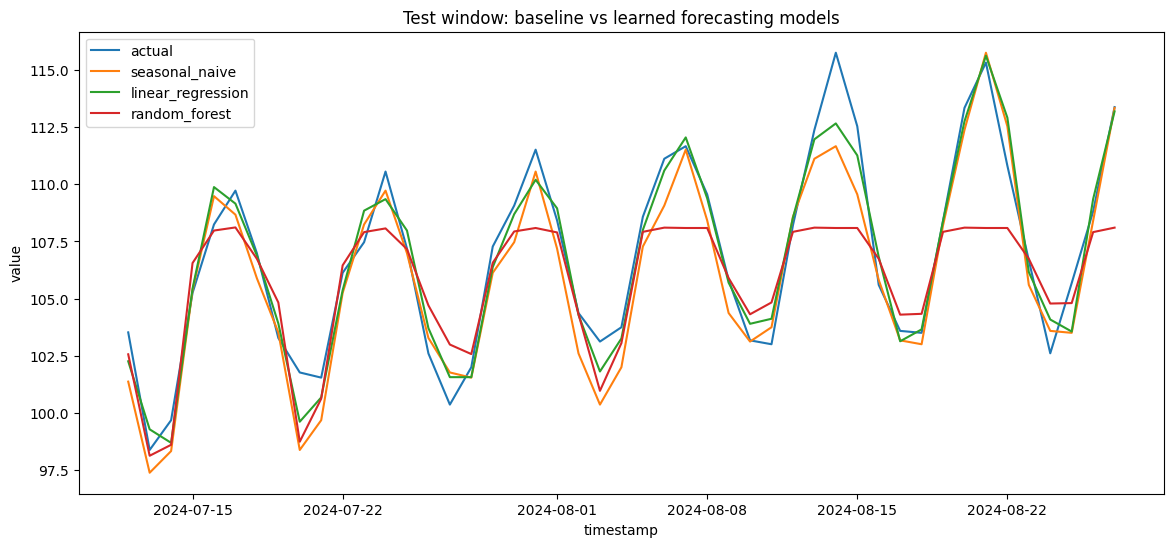

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(plot_df["timestamp"], plot_df["actual"], label="actual")
plt.plot(plot_df["timestamp"], plot_df["seasonal_naive"], label="seasonal_naive")
plt.plot(plot_df["timestamp"], plot_df["linear_regression"], label="linear_regression")
plt.plot(plot_df["timestamp"], plot_df["random_forest"], label="random_forest")
plt.title("Test window: baseline vs learned forecasting models")
plt.xlabel("timestamp")
plt.ylabel("value")
plt.legend()
plt.show()


In [11]:
# TODO: use real M4 daily data
# TODO: add rolling-origin evaluation
# TODO: extend to multi-step forecasts
# TODO: compare LLM-assisted model selection or feature suggestions later
planned_todos = [
    "use real M4 daily data",
    "add rolling-origin evaluation",
    "extend to multi-step forecasts",
    "compare LLM-assisted model selection or feature suggestions later",
]
print("Planned next steps:")
for t in planned_todos:
    print("-", t)


Planned next steps:
- use real M4 daily data
- add rolling-origin evaluation
- extend to multi-step forecasts
- compare LLM-assisted model selection or feature suggestions later


In [12]:
print("Day 5 completed: compared forecasting models on a one-step-ahead protocol.")


Day 5 completed: compared forecasting models on a one-step-ahead protocol.
